# 3:1:1 mixture

In [1]:
import gamdpy as gp
import h5py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os.path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator
plt.style.use('physrev')

In [2]:
gp.select_gpu()

# Specify statepoint
num_part = 2000
rho = 1.200
temperature = 5.00
qA = 0.5
qB = -4*qA

# Integrator params
dt = 0.004  # timestep
num_timeblocks = 32           # Do simulation in this many 'blocks'. 
steps_per_timeblock = 1*512  # ... each of this many steps

Using device 0


Text(0.5, 1.0, '$\\kappa=$1.00')

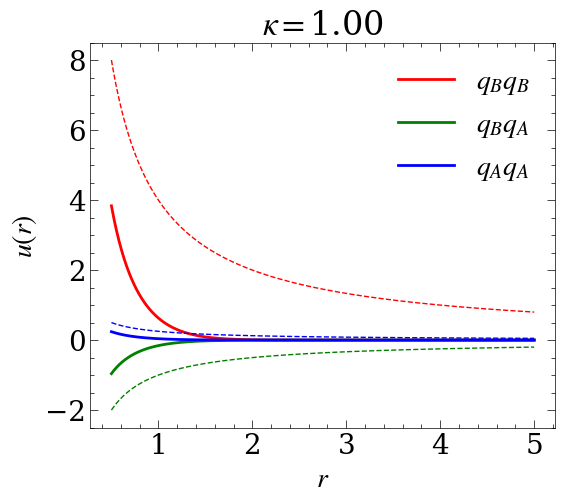

In [2]:
# Setup configuration: 
charges = [0, qA, qB]
conf = gp.Configuration(D=3, compute_flags={'U': True, 'K': True})
conf.make_positions(N=num_part, rho=rho)
conf['m'] = 1.0 # Specify all masses to unity 
conf.randomize_velocities(temperature=temperature, seed=1) # Initial high temperature for randomizing
conf.ptype[::5] = 1 # 4-1 mixture
# n0 = int(0.6*num_part)
# n1 = int(0.8*num_part)
# conf.ptype[n0:n1+1] = 1
# conf.ptype[n1:] = 2

# Setup charges
type0 = np.argwhere(conf.ptype == 0).flatten()
type1 = np.argwhere(conf.ptype == 1).flatten()
conf['q'][type1] = qB
conf['q'][type0[::4]] = qA

# Setup pair potential: Binary Kob-Andersen LJ mixture + coulomb.
# Potential parameters
sig = [[1.00, 0.80],
       [0.80, 0.88]]
eps = [[1.00, 1.50],
       [1.50, 0.50]]
cut = np.array(sig)*2.5

pair_func = gp.apply_shifted_force_cutoff(gp.LJ_12_6_sigma_epsilon)
pair_pot = gp.PairPotential(pair_func, params=[sig, eps, cut], max_num_nbs=2000)

damping = 1.0
cut_erfc = np.full((2,2), 5.0)
electro_pot = gp.Electrostatics(damping=damping, cutoff=cut_erfc)
integrator = gp.integrators.NVT(temperature=temperature, tau=0.2, dt=dt)

# Setup runtime actions, i.e. actions performed during simulation of timeblocks
runtime_actions = [gp.TrajectorySaver(), gp.RestartSaver(), gp.ScalarSaver(32), gp.MomentumReset(100)]
compute_plan = gp.get_default_compute_plan(conf)
electro_pot.set_ewald(nk=[8,8,8])
electro_pot.get_params(conf, compute_plan)

labels = [r'$q_B$', r'$q_A$']
colors = ['r', 'g', 'b']
r = np.linspace(0.5, 5, 500)
idx = 0
fig, ax = plt.subplots()
for i in range(2):
    for j in range(i, 2):
        u_r = [gp.gaussian_screened_coulomb(x, electro_pot.params[i,j])[0] for x in r]
        coul = [gp.make_IPL_n(n=1)(x, electro_pot.params[i,j])[0] for x in r]
        plt.plot(r, u_r, label=labels[i]+labels[j], marker='none', lw=2, color=colors[idx])
        plt.plot(r, coul, marker='none', ls='--', color=colors[idx])
        idx += 1
plt.legend(frameon=False)
plt.xlabel(r'$r$')
plt.ylabel(r'$u(r)$')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.title(r'$\kappa=$'+f'{damping:.2f}')
# ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=10))

In [3]:
len(electro_pot.charged_idx)

800

In [4]:
sim = gp.Simulation(conf, [pair_pot, electro_pot], integrator, runtime_actions, 
                    num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                    compute_plan=compute_plan, storage="memory") 

# Equilibration
print('Equilibrating.............')
for block in sim.run_timeblocks():
    print(f'{sim.status(per_particle=True)}')
print(sim.summary())
        
# Production
print('Running............')
for block in sim.run_timeblocks():
    print(f'{sim.status(per_particle=True)}')
print(sim.summary())

Equilibrating.............
timeblock= 0     time= 2.048       U= -0.657    W= 30.318    K= 7.577     
timeblock= 1     time= 4.096       U= -1.014    W= 28.575    K= 7.505     
timeblock= 2     time= 6.144       U= -0.733    W= 30.001    K= 7.505     
timeblock= 3     time= 8.192       U= -0.775    W= 29.786    K= 7.602     
timeblock= 4     time= 10.240      U= -0.870    W= 29.386    K= 7.584     
timeblock= 5     time= 12.288      U= -0.862    W= 29.413    K= 7.525     
timeblock= 6     time= 14.336      U= -0.937    W= 28.888    K= 7.390     
timeblock= 7     time= 16.384      U= -0.930    W= 28.985    K= 7.626     
timeblock= 8     time= 18.432      U= -0.861    W= 29.309    K= 7.541     
timeblock= 9     time= 20.480      U= -0.901    W= 28.981    K= 7.617     
timeblock= 10    time= 22.528      U= -0.946    W= 29.013    K= 7.413     
timeblock= 11    time= 24.576      U= -0.772    W= 29.807    K= 7.436     
timeblock= 12    time= 26.624      U= -1.035    W= 28.464    K= 7.294    

# Molten salt

Using device 0


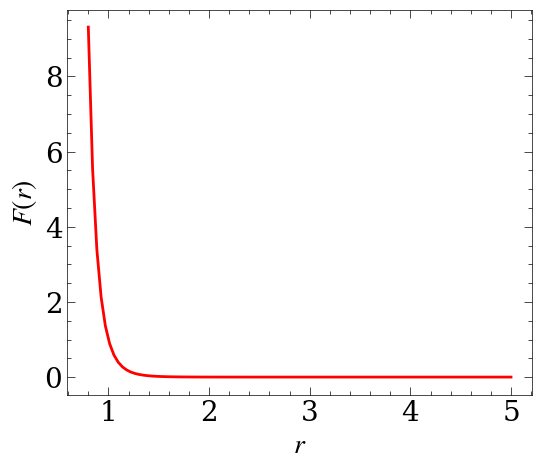

In [2]:
gp.select_gpu()

# Specify statepoint
num_part = 1000
rho = 0.368
temperature = 0.0177
qA = -1
qB = 1
qs = [qA, qB]

# Setup configuration:
def make_conf():
    configuration = gp.Configuration(D=3, compute_flags={'U': True, 'K': True})
    configuration.make_positions(N=num_part, rho=rho)
    configuration['m'] = 1.0 # Specify all masses to unity
    configuration.randomize_velocities(temperature=temperature, seed=1) # Initial high temperature for randomizing
    configuration.ptype[::2] = 1
    configuration.set_charges_from_types(qs)
    return configuration
    
configuration = make_conf()
# Setup pair potential
n = 9.0
vdw = gp.make_IPL_n(n=n)
eps = np.full((2,2), 1.0/n)
# vdw = gp.LJ_12_6_sigma_epsilon
# eps = np.full((2,2,), 1.0)
# sigma = np.full((2,2), 1.0)
rc = 2.0

cut = np.full((2,2), rc) # 2.0**(1.0/6.0))

pair_func = gp.apply_shifted_potential_cutoff(vdw)
pair_pot = gp.PairPotential(pair_func, params=[eps, cut], max_num_nbs=1000)

fig, ax = plt.subplots()
rs = np.linspace(0.8, 5, 100)
us = np.array([vdw(r, eps[0])[1]*r for r in rs])
plt.xlabel(r'$r$')
plt.ylabel(r'$F(r)$')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.plot(rs, us, color='r', lw=2, marker='none')


In [3]:
configuration.simbox.get_lengths()

array([13.9546, 13.9546, 13.9546], dtype=float32)

Text(0.5, 1.0, '$\\kappa=$1.00')

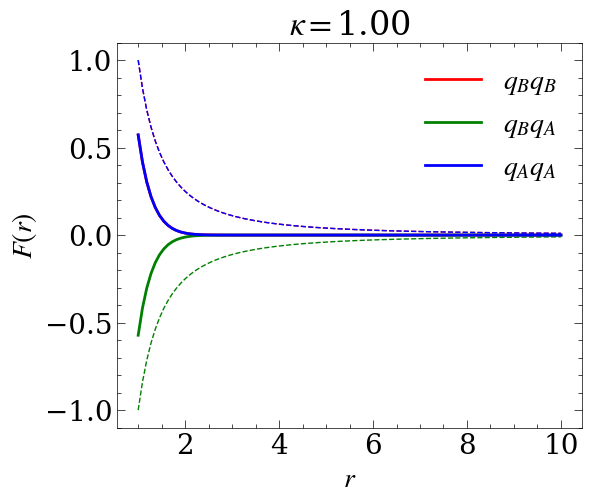

In [4]:
compute_plan = gp.get_default_compute_plan(configuration)

damping = 1
rcq = 3
cut_q = np.full((2,2), rcq)
electro_pot = gp.Electrostatics(damping=damping, cutoff=cut_q)
electro_pot.set_ewald(ncut=1)
electro_pot.get_params(configuration, compute_plan)

r = np.linspace(1, 10, 100)
labels = [r'$q_B$', r'$q_A$']
colors = ['r', 'g', 'b']
idx = 0
fig, ax = plt.subplots()
for i in range(2):
    for j in range(i, 2):
        u_r = [gp.gaussian_screened_coulomb(x, electro_pot.params[i,j])[1]*x for x in r]
        coul = [gp.make_IPL_n(n=1)(x, electro_pot.params[i,j])[1]*x for x in r]
        plt.plot(r, u_r, label=labels[i]+labels[j], marker='none', lw=2, color=colors[idx])
        plt.plot(r, coul, marker='none', ls='--', color=colors[idx])
        idx += 1
plt.legend(frameon=False)
plt.xlabel(r'$r$')
plt.ylabel(r'$F(r)$')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.title(r'$\kappa=$'+f'{damping:.2f}')

In [5]:
electro_pot.poisson

array([0.0216831, 0.0216831, 0.0216831], dtype=float32)

In [15]:
# Setting up simulation
dt = 0.01  # timestep
num_timeblocks = 32           # Do simulation in this many 'blocks'.
steps_per_timeblock = 1024  # ... each of this many steps
runtime_actions = [gp.TrajectorySaver(), gp.RestartSaver(), gp.ScalarSaver(32), gp.MomentumReset(100)]

integrator = gp.integrators.NVT(temperature=temperature, tau=0.2, dt=dt)

Us = []
rdfs = []
dyns = []

damping = 1
rcq = 3
cut_q = np.full((2,2), rcq)
ns = range(1, 20)
pp = True

In [16]:
for n in ns:
    print('##########################')
    print(f'Summing over the first {n} shells of replicas...')
    configuration = make_conf()
    electro_pot = gp.Electrostatics(damping=damping, cutoff=cut_q)
    electro_pot.set_ewald(ncut=n)
    sim = gp.Simulation(configuration, [pair_pot, electro_pot], integrator, runtime_actions,
                    num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                    compute_plan=compute_plan, storage="memory")
    calc_rdf = gp.CalculatorRadialDistribution(configuration, bins=500)
    # Equilibration
    print('Equilibrating.............')
    for block in sim.run_timeblocks():
        print(f'{sim.status(per_particle=pp)}')
    
    # Production
    print('Running............')
    for block in sim.run_timeblocks():
        calc_rdf.update()
        print(f'{sim.status(per_particle=pp)}')
    print(sim.summary())
    
    # Us.append(np.mean(gp.ScalarSaver.extract(sim.output, ['U'], per_particle=pp)))
    Us.append(gp.ScalarSaver.extract(sim.output, ['U'], per_particle=pp))
    rdfs.append(calc_rdf.read())
    dyn = gp.tools.calc_dynamics(sim.output, 0, qvalues=2*np.pi)
    dyns.append(dyn)

##########################
Summing over the first 1 shells of replicas...


/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Equilibrating.............
timeblock= 0     time= 10.240      U= -0.059    W= 0.019     K= 0.027     
timeblock= 1     time= 20.480      U= -0.059    W= 0.017     K= 0.027     
timeblock= 2     time= 30.720      U= -0.060    W= 0.017     K= 0.027     
timeblock= 3     time= 40.960      U= -0.060    W= 0.022     K= 0.027     
timeblock= 4     time= 51.200      U= -0.059    W= 0.019     K= 0.027     
timeblock= 5     time= 61.440      U= -0.059    W= 0.015     K= 0.027     
timeblock= 6     time= 71.680      U= -0.059    W= 0.020     K= 0.027     
timeblock= 7     time= 81.920      U= -0.058    W= 0.018     K= 0.027     
timeblock= 8     time= 92.160      U= -0.058    W= 0.026     K= 0.027     
timeblock= 9     time= 102.400     U= -0.059    W= 0.020     K= 0.027     
timeblock= 10    time= 112.640     U= -0.057    W= 0.024     K= 0.027     
timeblock= 11    time= 122.880     U= -0.059    W= 0.019     K= 0.027     
timeblock= 12    time= 133.120     U= -0.061    W= 0.016     K= 0.027    

/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Equilibrating.............
timeblock= 0     time= 10.240      U= -0.059    W= 0.015     K= 0.027     
timeblock= 1     time= 20.480      U= -0.060    W= 0.020     K= 0.027     
timeblock= 2     time= 30.720      U= -0.059    W= 0.019     K= 0.027     
timeblock= 3     time= 40.960      U= -0.059    W= 0.021     K= 0.027     
timeblock= 4     time= 51.200      U= -0.059    W= 0.023     K= 0.027     
timeblock= 5     time= 61.440      U= -0.058    W= 0.020     K= 0.027     
timeblock= 6     time= 71.680      U= -0.058    W= 0.017     K= 0.027     
timeblock= 7     time= 81.920      U= -0.060    W= 0.017     K= 0.027     
timeblock= 8     time= 92.160      U= -0.060    W= 0.019     K= 0.027     
timeblock= 9     time= 102.400     U= -0.059    W= 0.020     K= 0.027     
timeblock= 10    time= 112.640     U= -0.060    W= 0.020     K= 0.027     
timeblock= 11    time= 122.880     U= -0.057    W= 0.022     K= 0.027     
timeblock= 12    time= 133.120     U= -0.059    W= 0.024     K= 0.027    

...

Equilibrating.............
timeblock= 0     time= 10.240      U= -0.039    W= 0.036     K= 0.027     
timeblock= 1     time= 20.480      U= -0.039    W= 0.033     K= 0.027     
timeblock= 2     time= 30.720      U= -0.039    W= 0.037     K= 0.027     
timeblock= 3     time= 40.960      U= -0.040    W= 0.036     K= 0.027     
timeblock= 4     time= 51.200      U= -0.041    W= 0.031     K= 0.027     
timeblock= 5     time= 61.440      U= -0.040    W= 0.033     K= 0.027     
timeblock= 6     time= 71.680      U= -0.040    W= 0.033     K= 0.027     
timeblock= 7     time= 81.920      U= -0.041    W= 0.030     K= 0.027     
timeblock= 8     time= 92.160      U= -0.040    W= 0.036     K= 0.027     
timeblock= 9     time= 102.400     U= -0.040    W= 0.036     K= 0.027     
timeblock= 10    time= 112.640     U= -0.040    W= 0.032     K= 0.027     
timeblock= 11    time= 122.880     U= -0.039    W= 0.036     K= 0.027     
timeblock= 12    time= 133.120     U= -0.039    W= 0.031     K= 0.027    

/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Equilibrating.............
timeblock= 0     time= 10.240      U= -0.039    W= 0.036     K= 0.027     
timeblock= 1     time= 20.480      U= -0.039    W= 0.034     K= 0.027     
timeblock= 2     time= 30.720      U= -0.040    W= 0.035     K= 0.027     
timeblock= 3     time= 40.960      U= -0.040    W= 0.031     K= 0.027     
timeblock= 4     time= 51.200      U= -0.040    W= 0.029     K= 0.027     
timeblock= 5     time= 61.440      U= -0.040    W= 0.032     K= 0.027     
timeblock= 6     time= 71.680      U= -0.039    W= 0.033     K= 0.027     
timeblock= 7     time= 81.920      U= -0.039    W= 0.030     K= 0.027     
timeblock= 8     time= 92.160      U= -0.039    W= 0.031     K= 0.027     
timeblock= 9     time= 102.400     U= -0.040    W= 0.031     K= 0.027     
timeblock= 10    time= 112.640     U= -0.040    W= 0.031     K= 0.027     
timeblock= 11    time= 122.880     U= -0.040    W= 0.035     K= 0.027     
timeblock= 12    time= 133.120     U= -0.041    W= 0.033     K= 0.027    

/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/net/debye/stud-nikitaall/summerschool/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 125 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Equilibrating.............
timeblock= 0     time= 10.240      U= -0.039    W= 0.036     K= 0.027     
timeblock= 1     time= 20.480      U= -0.039    W= 0.034     K= 0.027     
timeblock= 2     time= 30.720      U= -0.041    W= 0.032     K= 0.027     
timeblock= 3     time= 40.960      U= -0.041    W= 0.034     K= 0.027     
timeblock= 4     time= 51.200      U= -0.040    W= 0.033     K= 0.027     
timeblock= 5     time= 61.440      U= -0.040    W= 0.039     K= 0.027     
timeblock= 6     time= 71.680      U= -0.040    W= 0.028     K= 0.027     
timeblock= 7     time= 81.920      U= -0.040    W= 0.036     K= 0.027     
timeblock= 8     time= 92.160      U= -0.040    W= 0.033     K= 0.027     
timeblock= 9     time= 102.400     U= -0.038    W= 0.038     K= 0.027     
timeblock= 10    time= 112.640     U= -0.040    W= 0.038     K= 0.027     
timeblock= 11    time= 122.880     U= -0.040    W= 0.030     K= 0.027     
timeblock= 12    time= 133.120     U= -0.039    W= 0.033     K= 0.027    

In [17]:
charges, _ = configuration.get_charged_particles()
self_term = np.sum(charges**2) * damping / np.sqrt(np.pi)

In [18]:
np.array(Us).flatten()-self_term/configuration.N

array([-0.62408594, -0.62422645, -0.62404006, ..., -0.60362735,
       -0.6035715 , -0.60341772], shape=(19456,))

In [19]:
(np.mean(np.array(Us), axis=-1).flatten()*configuration.N-self_term)/configuration.N

array([-0.62324554, -0.62329417, -0.62318253, -0.6230388 , -0.6229379 ,
       -0.62267878, -0.62202618, -0.62083133, -0.61296589, -0.60509216,
       -0.6040915 , -0.60402939, -0.6039564 , -0.60394706, -0.60404652,
       -0.60403543, -0.60405616, -0.60391466, -0.60390285])

In [20]:
A = (np.mean(np.array(Us), axis=-1).flatten()*configuration.N-self_term)/configuration.N

In [21]:
A#.mean()

array([-0.62324554, -0.62329417, -0.62318253, -0.6230388 , -0.6229379 ,
       -0.62267878, -0.62202618, -0.62083133, -0.61296589, -0.60509216,
       -0.6040915 , -0.60402939, -0.6039564 , -0.60394706, -0.60404652,
       -0.60403543, -0.60405616, -0.60391466, -0.60390285])

Text(0, 0.5, '$U/Nk_{\\mathrm{B}}T$')

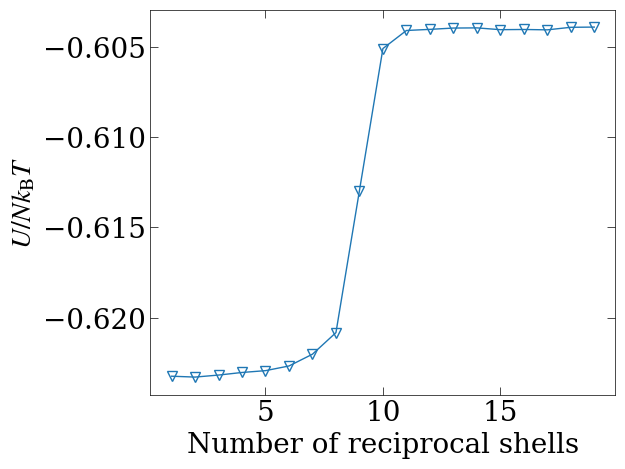

In [22]:
Us = np.array(Us)
plt.plot(ns, A)
# plt.axhline(y=-33.52*temperature)
plt.xlabel('Number of reciprocal shells')
plt.ylabel(r'$U/Nk_{\mathrm{B}}T$')

In [9]:
(Us*configuration.N-self_term)/(configuration.N)

array([-0.66701017])

In [21]:
-33.52*temperature

-0.593304

In [24]:
# Hansen & McDonald
r = [0.0, 0.084, 0.167, 0.251, 0.335, 0.419, 0.502, 0.586, 0.670,
     0.754, 0.837, 0.921, 0.963, 1.005, 1.047, 1.088, 1.130, 1.172,
     1.214, 1.256, 1.298, 1.340, 1.382, 1.423, 1.465, 1.507, 1.549,
     1.591, 1.633, 1.674, 1.716, 1.758, 1.800, 1.842, 1.926,
     2.010, 2.093, 2.177, 2.261, 2.344, 2.428, 2.512, 2.596, 2.721,
     2.847, 2.972, 3.098, 3.224, 3.349, 3.475, 3.600, 3.726, 3.852]

g1 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
      0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.002, 0.009,
      0.028, 0.068, 0.140, 0.251, 0.401, 0.586, 0.790, 1.001, 1.198,
      1.368, 1.502, 1.590, 1.642, 1.658, 1.650, 1.621, 1.526,
      1.413, 1.289, 1.145, 0.997, 0.873, 0.783, 0.731, 0.712, 0.735,
      0.809, 0.913, 1.027, 1.118, 1.167, 1.165, 1.124, 1.059, 1.001]

g2 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
      0.0, 0.0, 0.048, 0.516, 1.882, 3.489, 4.275, 4.115, 3.453,
      2.718, 2.094, 1.612, 1.269, 1.016, 0.844, 0.720, 0.632, 0.572,
      0.530, 0.503, 0.487, 0.481, 0.484, 0.492, 0.508, 0.556,
      0.625, 0.712, 0.823, 0.947, 1.078, 1.199, 1.285, 1.321, 1.285,
      1.182, 1.059, 0.954, 0.880, 0.845, 0.844, 0.875, 0.931, 0.997]

Text(0, 0.5, '$g(r)$')

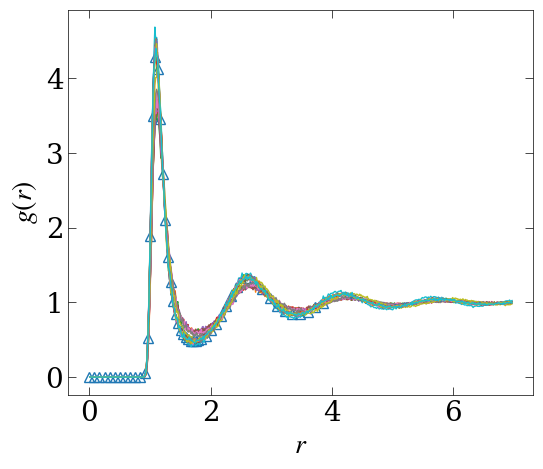

In [27]:
plt.plot(r, g2, '^')
for i in range(len(ns)):
    plt.plot(rdfs[i]['distances'], rdfs[i]['rdf'][:, 0, 1], marker='none')
plt.xlabel(r'$r$')
plt.ylabel(r'$g(r)$')

Text(0, 0.5, 'MSD')

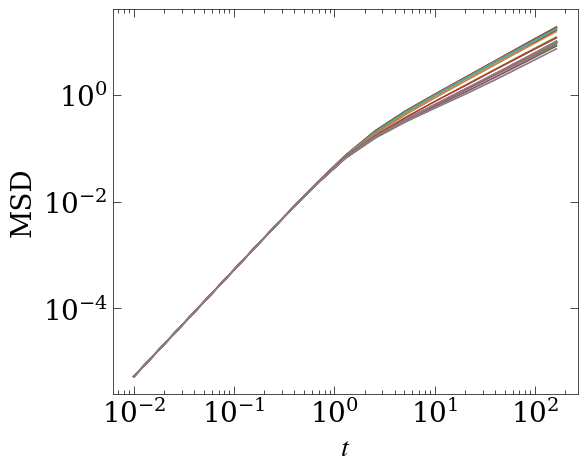

In [28]:
for i in range(len(ns)):
    t = dyns[i]['times']
    plt.loglog(t, dyns[i]['msd'], marker='none')
plt.xlabel(r'$t$')
plt.ylabel(r'MSD')

In [12]:
x = 5.0
gp.gaussian_screened_coulomb(x, [1, 0.5])[0]

np.float32(8.1390404e-05)

In [13]:
charges, _ = configuration.get_charged_particles()
self_term = np.sum(charges**2) * damping / np.sqrt(np.pi)
U = np.array([i*configuration.N-self_term for i in Us])
U/(configuration.N*temperature)

array([-34.1214233 , -34.14111834, -34.15960476, -34.15220295,
       -34.14167697, -34.15445297, -34.16643759, -34.17081178,
       -34.15960131, -34.16367204, -34.15052535, -34.1890637 ,
       -34.15587713, -34.15520816, -34.18871715, -34.16045994,
       -34.1671238 , -34.17221524, -34.16115995])

## Shifted force

In [26]:
rcq = 10.0
cut_q = np.full((2,2), rcq)
params_q = [[1.0, -1.0],[-1.0, 1.0]]
dampingM = np.full((2,2), damping)
configuration = make_conf()
electro_pot = gp.add_potential_functions(gp.make_IPL_n(n=9), gp.make_IPL_n(n=1, first_parameter=1))
pairpot= gp.apply_shifted_force_cutoff(electro_pot)
pot = gp.PairPotential(pairpot, params=[eps, params_q, cut_q], max_num_nbs=6000)
# electro_pot = gp.PairPotential(gp.apply_shifted_force_cutoff(gp.make_IPL_n(n=1)), params=[params_q, cut_q], max_num_nbs=6000)
# electro_pot = gp.PairPotential(gp.apply_shifted_force_cutoff(gp.gaussian_screened_coulomb), params=[params_q, dampingM, cut_q], max_num_nbs=2000)

sim = gp.Simulation(configuration, pot, integrator, runtime_actions,
                num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                compute_plan=compute_plan, storage="memory")
calc_rdf = gp.CalculatorRadialDistribution(configuration, bins=500)
# Equilibration
print('Equilibrating.............')
for block in sim.run_timeblocks():
    print(f'{sim.status(per_particle=True)}')

# Production
print('Running............')
for block in sim.run_timeblocks():
    calc_rdf.update()
    print(f'{sim.status(per_particle=True)}')
print(sim.summary())

U = np.mean(gp.ScalarSaver.extract(sim.output, ['U'], per_particle=False))
rdf = calc_rdf.read()
dyn = gp.tools.calc_dynamics(sim.output, 0, qvalues=2*np.pi)

Equilibrating.............
timeblock= 0     time= 4.096       U= -0.510    W= -0.012    K= 0.027     
timeblock= 1     time= 8.192       U= -0.511    W= -0.013    K= 0.027     
timeblock= 2     time= 12.288      U= -0.511    W= -0.010    K= 0.027     
timeblock= 3     time= 16.384      U= -0.510    W= -0.011    K= 0.027     
timeblock= 4     time= 20.480      U= -0.510    W= -0.010    K= 0.027     
timeblock= 5     time= 24.576      U= -0.509    W= -0.010    K= 0.027     
timeblock= 6     time= 28.672      U= -0.508    W= -0.009    K= 0.027     
timeblock= 7     time= 32.768      U= -0.507    W= -0.009    K= 0.027     
timeblock= 8     time= 36.864      U= -0.507    W= -0.011    K= 0.027     
timeblock= 9     time= 40.960      U= -0.506    W= -0.012    K= 0.027     
timeblock= 10    time= 45.056      U= -0.506    W= -0.014    K= 0.027     
timeblock= 11    time= 49.152      U= -0.505    W= -0.013    K= 0.027     
timeblock= 12    time= 53.248      U= -0.505    W= -0.015    K= 0.027    

In [27]:
U/(configuration.N*temperature)

np.float32(-28.50701)

Text(0, 0.5, '$g(r)$')

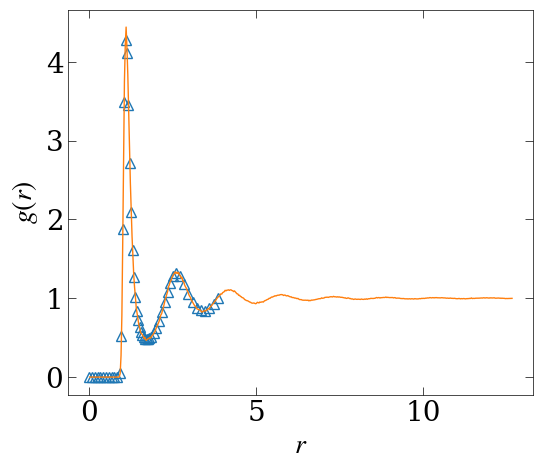

In [28]:
plt.plot(r, g2, '^')
plt.plot(rdf['distances'], rdf['rdf'][:, 0, 1], marker='none')
plt.xlabel(r'$r$')
plt.ylabel(r'$g(r)$')

In [30]:
rcq = 5.0
cut_q = np.full((2,2), rcq)
params_q = [[1.0, -1.0],[-1.0, 1.0]]
dampingM = np.full((2,2), damping)
configuration = make_conf()
# electro_pot = gp.add_potential_functions(gp.make_IPL_n(n=9), gp.make_IPL_n(n=1, first_parameter=1))
# pairpot= gp.apply_shifted_force_cutoff(electro_pot)
# pot = gp.PairPotential(pairpot, params=[eps, params_q, cut_q], max_num_nbs=6000)
# electro_pot = gp.PairPotential(gp.apply_shifted_force_cutoff(gp.make_IPL_n(n=1)), params=[params_q, cut_q], max_num_nbs=6000)
electro_pot = gp.PairPotential(gp.apply_shifted_force_cutoff(gp.gaussian_screened_coulomb), params=[params_q, dampingM, cut_q], max_num_nbs=2000)

sim = gp.Simulation(configuration, [pair_pot, electro_pot], integrator, runtime_actions,
                num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                compute_plan=compute_plan, storage="memory")
calc_rdf = gp.CalculatorRadialDistribution(configuration, bins=500)
# Equilibration
print('Equilibrating.............')
for block in sim.run_timeblocks():
    print(f'{sim.status(per_particle=True)}')

# Production
print('Running............')
for block in sim.run_timeblocks():
    calc_rdf.update()
    print(f'{sim.status(per_particle=True)}')
print(sim.summary())

U = np.mean(gp.ScalarSaver.extract(sim.output, ['U'], per_particle=False))
rdf = calc_rdf.read()
dyn = gp.tools.calc_dynamics(sim.output, 0, qvalues=2*np.pi)

Equilibrating.............
timeblock= 0     time= 4.096       U= -0.327    W= -0.014    K= 0.027     
timeblock= 1     time= 8.192       U= -0.327    W= -0.012    K= 0.027     
timeblock= 2     time= 12.288      U= -0.327    W= -0.009    K= 0.027     
timeblock= 3     time= 16.384      U= -0.326    W= -0.005    K= 0.027     
timeblock= 4     time= 20.480      U= -0.326    W= -0.006    K= 0.027     
timeblock= 5     time= 24.576      U= -0.325    W= -0.007    K= 0.027     
timeblock= 6     time= 28.672      U= -0.325    W= -0.009    K= 0.027     
timeblock= 7     time= 32.768      U= -0.324    W= -0.007    K= 0.027     
timeblock= 8     time= 36.864      U= -0.323    W= -0.010    K= 0.027     
timeblock= 9     time= 40.960      U= -0.323    W= -0.012    K= 0.027     
timeblock= 10    time= 45.056      U= -0.322    W= -0.014    K= 0.027     
timeblock= 11    time= 49.152      U= -0.322    W= -0.016    K= 0.027     
timeblock= 12    time= 53.248      U= -0.321    W= -0.015    K= 0.027    